# Pre-laboratorio

In [6]:
%pip install uncertainties

  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
Using cached uncertainties-3.2.3-py3-none-any.whl (60 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid, odeint
from scipy.fft import fft, ifft
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from uncertainties import ufloat
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from sympy import symbols, lambdify, sqrt, sin

### Rigidez resortes

In [8]:
calibrador_uncertainy = 0.00005
ll_baja = [ufloat(measurement, calibrador_uncertainy) for measurement in [ln1, ln2, ln3, ln4]] # configuración baja rigidez
lf_baja = [ufloat(measurement, calibrador_uncertainy) for measurement in [lf1, lf2, lf3, lf4]]

ll_media = [ufloat(measurement, calibrador_uncertainy) for measurement in [ln1, ln2, ln3, ln4]] # configuración media rigidez
lf_media = [ufloat(measurement, calibrador_uncertainy) for measurement in [lf1, lf2, lf3, lf4]]

ll_alta = [ufloat(measurement, calibrador_uncertainy) for measurement in [ln1, ln2, ln3, ln4] # alta rigidez
lf_alta = [ufloat(measurement, calibrador_uncertainy) for measurement in [lf1, lf2, lf3, lf4]]

SyntaxError: invalid syntax (1225354218.py, line 9)

In [9]:
springMass = ufloat(MASA_SELECCIONADA, 0.0001) # masa seleccionada para hacer la prueba
gravity = ufloat(-9.774, 0.001)

k_baja = []
k_media = []
k_alta = []
for i in range(len(ll_baja)):
  k_baja.append(springMass*gravity/(-(lf_baja[i] - ll_baja[i]))) # K de baja
  k_media.append(springMass*gravity/(-(lf_media[i] - ll_media[i]))) # K de los de media
  k_alta.append(springMass*gravity/(-(lf_alta[i] - ll_alta[i]))) # K de los de alta

k_baja = np.mean(k_baja)
k_media = np.mean(k_media)
k_alta = np.mean(k_alta)

print(k_baja, k_media, k_alta)

NameError: name 'MASA_SELECCIONADA' is not defined

### Frecuencia natural sistema

La expresión de la frecuencia natural está dada por:

$$
\omega_n = \sqrt{\frac{k}{m}}
$$



In [10]:
N = #numero de resortes pueden usar toda la configuración o 4
accelerationMass = 2.90
omega_n = ((N*k_media)/accelerationMass)**(1/2)
print(omega_n)
omega_n = omega_n.n

SyntaxError: invalid syntax (67151693.py, line 1)

### Factor de amortiguamiento

In [11]:
dataDf = pd.read_csv("nombre_de_equipo.txt", usecols=[0,2], names=["t", "Sensor 2"], sep="\t", decimal=",")
dataDf['acceleration'] = dataDf['Sensor 2'] * factor_de_sensibilidad # Depende del sensor que seleccionen

plt.figure(figsize=(9,6))
plt.plot(dataDf["t"], dataDf["acceleration"], label= r"Aceleración masa $(\frac{m}{s^2})$")
plt.title("Medición Acelerometro Vs. Tiempo")
plt.ylabel(r"Aceleración $(\frac{m}{s^2})$")
plt.xlabel("Tiempo ($s$)")
plt.grid()
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'nombre_de_equipo.txt'

In [13]:
dataDf['acceleration'] = dataDf['acceleration'] - np.mean(dataDf['acceleration']) # desfase restado

NameError: name 'dataDf' is not defined

In [15]:
test1Df = dataDf[(TIEMPO_MIN < dataDf['t']) & (dataDf['t'] < TIEMPO_MAX)].copy()
plt.plot(test1Df['t'], test1Df['acceleration'], label= r"Aceleración masa $(\frac{m}{s^2})$")
plt.title("Ensayo 1")
plt.ylabel(r"Aceleración $(\frac{m}{s^2})$")
plt.xlabel("Tiempo ($s$)")
plt.legend()
plt.grid()
plt.show()

NameError: name 'dataDf' is not defined

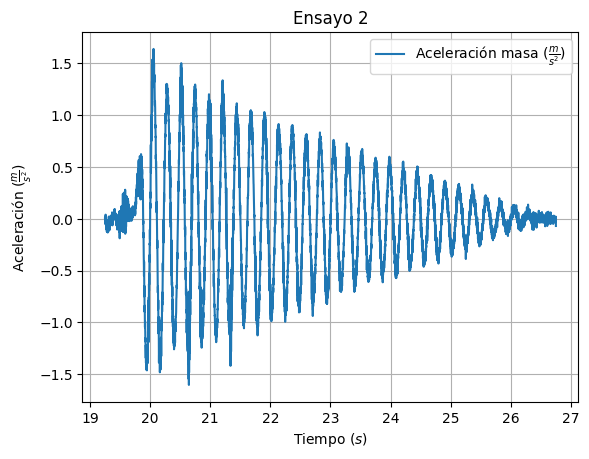

In [ ]:
test2Df = dataDf[(TIEMPO_MIN2 < dataDf['t']) & (dataDf['t'] < TIEMPO_MAX2)].copy()
plt.plot(test2Df['t'], test2Df['acceleration'], label= r"Aceleración masa $(\frac{m}{s^2})$")
plt.title("Ensayo 2")
plt.ylabel(r"Aceleración $(\frac{m}{s^2})$")
plt.xlabel("Tiempo ($s$)")
plt.legend()
plt.grid()
plt.show()

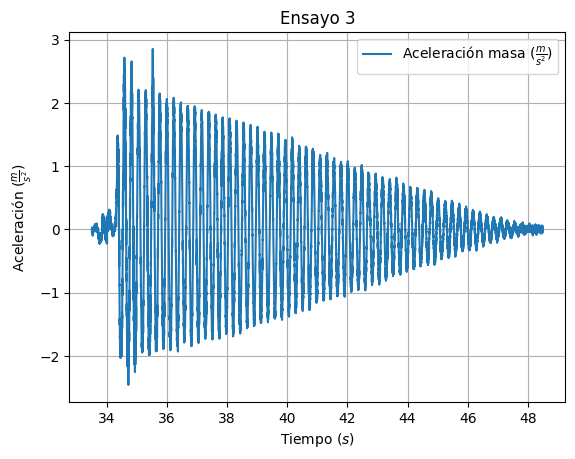

In [ ]:
test3Df = dataDf[(TIEMPO_MIN3 < dataDf['t']) & (dataDf['t'] < TIEMPO_MAX3)].copy()
plt.plot(test3Df['t'], test3Df['acceleration'], label= r"Aceleración masa $(\frac{m}{s^2})$")
plt.title("Ensayo 3")
plt.ylabel(r"Aceleración $(\frac{m}{s^2})$")
plt.xlabel("Tiempo ($s$)")
plt.legend()
plt.grid()
plt.show()

In [16]:
def fourier(t, datos, frec_corte_bajo, frec_corte_alto, frec_muestreo=1000, threshold=0, supTitle=None):

    # Aplicar FFT y crear la máscara de filtrado
    fft_resultado = fft(datos)
    freqs = np.fft.fftfreq(len(datos), d=1/frec_muestreo)
    mask = (np.abs(freqs) >= frec_corte_bajo) & (np.abs(freqs) <= frec_corte_alto)
    fft_filtrado = fft_resultado * mask  # Solo conservar frecuencias dentro del rango

    # Transformada inversa para obtener los datos filtrados
    datos_filtrados = np.real(ifft(fft_filtrado))


    # Graficar los resultados
    plt.figure(figsize=(9, 5))

    # Gráfico del espectro frecuencial
    plt.subplot(2, 1, 1)
    plt.title('Gráfico del espectro frecuencial')
    plt.plot(np.abs(freqs)[mask], np.abs(fft_resultado)[mask], label='Frecuencias originales')
    plt.plot(np.abs(freqs)[mask], np.abs(fft_filtrado)[mask], label='Frecuencias filtradas')
    plt.ylabel('Amplitud')
    plt.xlabel('Frecuencia $(Hz)$')
    plt.grid()
    plt.legend()

    # Gráfico de los datos originales y filtrados
    plt.subplot(2, 1, 2)
    plt.scatter(t, datos, s=4, label='Datos originales')
    plt.plot(t, datos_filtrados, c='red', label='Datos filtrados')
    plt.title('Gráfico de los datos originales y filtrados')
    plt.ylabel(r'Aceleración $(\frac{m}{s^2})$')
    plt.xlabel("Tiempo ($s$)")
    plt.grid()
    plt.legend()

    if supTitle != None:
      plt.suptitle(supTitle)

    plt.tight_layout()
    plt.show()

    return datos_filtrados


test1Df['filtered accel.'] = fourier(test1Df['t'], test1Df['acceleration'], 2, 6,threshold=313)

NameError: name 'test1Df' is not defined

In [17]:
test2Df['filtered accel.'] = fourier(test2Df['t'], test2Df['acceleration'], 2, 6)

NameError: name 'test2Df' is not defined

In [18]:
test3Df['filtered accel.'] = fourier(test3Df['t'], test3Df['acceleration'], 2, 6)

NameError: name 'test3Df' is not defined

In [ ]:
test1Df['velocity'] = cumulative_trapezoid(test1Df['filtered accel.'], test1Df['t'], initial=0)
test1Df['velocity'] = test1Df['velocity'] - np.mean(test1Df['velocity'])
test1Df['position'] = cumulative_trapezoid(test1Df['velocity'], test1Df['t'], initial=0)

test2Df['velocity'] = cumulative_trapezoid(test2Df['filtered accel.'], test2Df['t'], initial=0)
test2Df['velocity'] = test2Df['velocity'] - np.mean(test2Df['velocity'])
test2Df['position'] = cumulative_trapezoid(test2Df['velocity'], test2Df['t'], initial=0)

test3Df['velocity'] = cumulative_trapezoid(test3Df['filtered accel.'], test3Df['t'], initial=0)
test3Df['velocity'] = test3Df['velocity'] - np.mean(test3Df['velocity'])
test3Df['position'] = cumulative_trapezoid(test3Df['velocity'], test3Df['t'], initial=0)

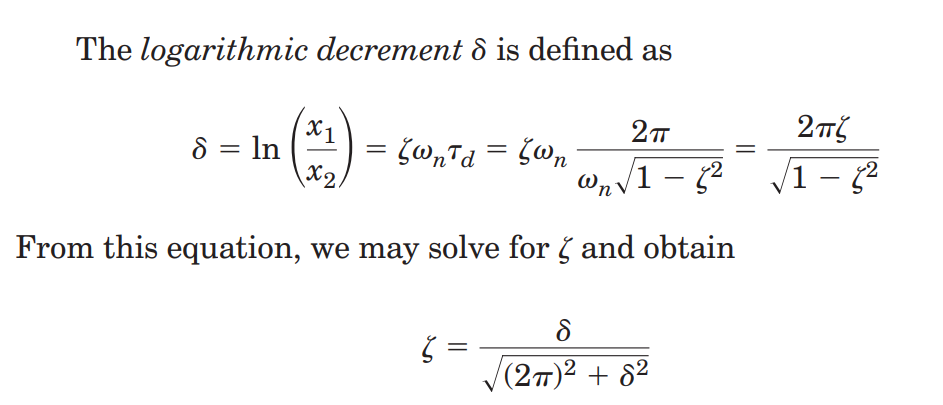


$$
\omega_d = \omega_n \sqrt{1-\zeta^2}
$$

El factor de magnificación para un sistema de 2do orden está dada por:

$$
M = \frac{1}{\sqrt{ (1 - (\frac{\omega}{\omega_n})^2 )^2  + (2 \zeta \frac{\omega}{\omega_n})^2}}
$$
